# Tabular regression with Amazon SageMaker AutoGluon-Tabular algorithm (V3)

---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

---

> **SageMaker Python SDK v3 note:** This notebook has been migrated to the SageMaker Python SDK **v3**. The JumpStart AutoGluon-Tabular workflow now uses the high-level v3 JumpStart APIs: `ModelTrainer.from_jumpstart_config(...)` for training (from `sagemaker-train`) and `ModelBuilder` for resource-chained deployment (from `sagemaker-serve`), backed by `sagemaker-core`. It no longer uses the v2 `image_uris`/`model_uris`/`script_uris` retrieval helpers together with the generic `Estimator`. Install with `pip install sagemaker` (v3).

---

---
This notebook demonstrates the use of Amazon SageMaker [AutoGluon-Tabular](https://auto.gluon.ai/stable/tutorials/tabular_prediction/index.html) algorithm to train and host a tabular regression model. Tabular regression is the task of analyzing the relationship between predictor variables and a response variable in a structured or relational data.

In this notebook, we demonstrate two use cases of tabular regression models:

* How to train a tabular model on an example dataset to do regression.
* How to use the trained tabular model to perform inference, i.e., predicting new samples.

Note: This notebook was tested in Amazon SageMaker Studio on ml.t3.medium instance with Python 3 (Data Science) kernel.

---

1. [Set Up](#1.-Set-Up)
2. [Train A Tabular Model on Abalone Dataset](#2.-Train-a-Tabular-Model-on-Abalone-Dataset)
    * [Set Training Parameters](#2.1.-Set-Training-Parameters)
    * [Start Training](#2.2.-Start-Training)
3. [Deploy and Run Inference on the Trained Tabular Model](#3.-Deploy-and-Run-Inference-on-the-Trained-Tabular-Model)
4. [Evaluate the Prediction Results Returned from the Endpoint](#4.-Evaluate-the-Prediction-Results-Returned-from-the-Endpoint)

## 1. Set Up

---
Before executing the notebook, there are some initial steps required for setup. This notebook requires the latest version of sagemaker (v3) and ipywidgets.

---

In [1]:
# [papermill-run] pip install disabled to preserve local env
pass


---
To train and host on Amazon SageMaker, we need to setup and authenticate the use of AWS services. Here, we use the execution role associated with the current notebook instance as the AWS account role with SageMaker access. It has necessary permissions, including access to your data in S3.

---

In [2]:
import boto3, json
from sagemaker.core.helper.session_helper import Session, get_execution_role
import boto3 as _boto3
sess = Session(boto_session=_boto3.Session(region_name="us-west-1"))  # [papermill-run] region-bound session
aws_role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [papermill-run] explicit role
aws_region = sess.boto_region_name


[07/09/26 13:54:59] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12068314;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12068315;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


## 2. Train a Tabular Model on Abalone Dataset

---

In this demonstration, we will train a tabular algorithm on the [Abalone](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression.html) dataset. The dataset contains examples of eight physical measurements such as length, diameter, and height to predict the age of abalone. Among the eight physical measurements (features), there are one categorical feature and seven numerical features. Abalone dataset is downloaded from [LIBSVM](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression.html).

Below is the table of the first 5 examples in the Abalone dataset.

| Target | Feature_0 | Feature_1 | Feature_2 | Feature_3 | Feature_4 | Feature_5 | Feature_6 | Feature_7 |
|:------:|:---------:|:---------:|:---------:|:---------:|:---------:|:---------:|:---------:|:---------:|
|   11   |     1     |   0.585   |   0.455   |   0.150   |  0.9870   |  0.4355   |  0.2075   |  0.3100   |
|   5    |     3     |   0.325   |   0.245   |   0.075   |  0.1495   |  0.0605   |  0.0330   |  0.0450   |
|   9    |     3     |   0.580   |   0.420   |   0.140   |  0.7010   |  0.3285   |  0.1020   |  0.2255   |
|   12   |     2     |   0.480   |   0.380   |   0.145   |  0.5900   |  0.2320   |  0.1410   |  0.2300   |
|   11   |     2     |   0.440   |   0.355   |   0.115   |  0.4150   |  0.1585   |  0.0925   |  0.1310   |

If you want to bring your own dataset, below are the instructions on how the training data should be formatted as input to the model.

A S3 path should contain two sub-directories 'train/', and 'validation/' (optional). Each sub-directory contains a 'data.csv' file (The Abalone dataset used in this example has been prepared and saved in `training_dataset_s3_path` shown below).

* The 'data.csv' files under sub-directory 'train/' and 'validation/' are for training and validation, respectively. The validation data is used to compute a validation score at the end of each training iteration or epoch. An early stopping is applied when the validation score stops improving. If the validation data is not provided, a fraction of training data is randomly sampled to serve as the validation data. The fraction value is selected based on the number of rows in the training data. Default values range from 0.2 at 2,500 rows to 0.01 at 250,000 rows. For details, see [AutoGluon-Tabular Documentation](https://auto.gluon.ai/stable/api/autogluon.predictor.html#autogluon.tabular.TabularPredictor.fit).
* The first column of the 'data.csv' should have the corresponding target variable. The rest of other columns should have the corresponding predictor variables (features).
* All the categorical and numeric features, and target can be kept as their original formats.


Citations:

- Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science


### 2.1. Set Training Parameters

---
Now that we are done with all the setup that is needed, we are ready to train our tabular algorithm.

In v3, we identify the JumpStart model with a `JumpStartConfig` (specifying the `model_id`). The `ModelTrainer.from_jumpstart_config(...)` factory automatically resolves the training container image, the training source code, the pre-trained model artifact, and the default hyperparameters for that model ID, so we no longer retrieve those artifacts manually.

For the training algorithm, we have one choice in this demonstration.
* [AutoGluon-Tabular](https://auto.gluon.ai/stable/tutorials/tabular_prediction/index.html): To use this algorithm, specify `train_model_id` as `autogluon-regression-ensemble` in the cell below.

There are two kinds of parameters that need to be set for training. The first one are the parameters for the training job. These include: (i) Training data path (S3 folder in which the input data is stored), (ii) Output path (the S3 folder in which the training output is stored), (iii) Training instance type (the type of machine on which to run the training).

The second set of parameters are algorithm specific training hyper-parameters.

---

In [3]:
train_model_id, train_model_version = "autogluon-regression-ensemble", "*"

# The JumpStart AutoGluon-Tabular model supports a specific set of training instance types.
# ml.g4dn.xlarge is the GPU instance in the supported list for this model.
training_instance_type = "ml.g4dn.xlarge"

# Sample training data is available in this bucket
training_data_bucket = f"jumpstart-cache-prod-{aws_region}"
training_data_prefix = "training-datasets/tabular_regress/"

training_dataset_s3_path = f"s3://{training_data_bucket}/{training_data_prefix}"

output_bucket = sess.default_bucket()
default_bucket_prefix = sess.default_bucket_prefix
output_prefix = "jumpstart-example-tabular-training"

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    output_prefix = f"{default_bucket_prefix}/{output_prefix}"

s3_output_location = f"s3://{output_bucket}/{output_prefix}/output"

---
For algorithm specific hyper-parameters, we start by fetching a python dictionary of the training hyper-parameters that the algorithm accepts with their default values. This can then be overridden to custom values.

---

In [4]:
from sagemaker.core import hyperparameters

# Retrieve the default hyper-parameters for training the model
hyperparameters = hyperparameters.retrieve_default(
    model_id=train_model_id, model_version=train_model_version
)

# [Optional] Override default hyperparameters with custom values
hyperparameters["auto_stack"] = "True"
print(hyperparameters)

[07/09/26 13:55:00] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12068320;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12068321;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Using model 'autogluon-regression-ensemble' with wildcard version identifier '*'. You can pin to version '2.0.21' for more stable results. Note that models may have different input/output signatures after a major version upgrade.


[07/09/26 13:55:01] WARNING  Using model 'autogluon-regression-ensemble' with wildcard version         ]8;id=12068328;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py\cache.py]8;;\:]8;id=12068329;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py#624\624]8;;\
                             identifier '*'. You can pin to version '2.0.21' for more stable results.              
                             Note that models may have different input/output signatures after a major             
                             version upgrade.                                                                      

{'eval_metric': 'auto', 'presets': 'medium_quality', 'auto_stack': 'True', 'num_bag_folds': '0', 'num_bag_sets': '1', 'num_stack_levels': '0', 'refit_full': 'False', 'set_best_to_refit_full': 'False', 'save_space': 'False', 'verbosity': '2'}


### 2.2. Start Training

---
We start by creating the `ModelTrainer` object from the JumpStart config with all the required assets and then launch the training job.
Note. We do not use hyperparameter tuning for AutoGluon models because [AutoGluon](https://arxiv.org/abs/2003.06505) succeeds by ensembling multiple models and stacking them in multiple layers rather than focusing on model/hyperparameter selection.

---

In [5]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import Compute, InputData
from sagemaker.core.jumpstart import JumpStartConfig
from sagemaker.core.shapes import OutputDataConfig

# Note: JumpStartConfig resolves the latest hub content version when model_version is
# left unset. (The public hub expects a full semantic version, not the '*' wildcard that
# the artifact-retrieval helpers accept.)
jumpstart_config = JumpStartConfig(
    model_id=train_model_id,
)

# Create the ModelTrainer from the JumpStart config. The training image, source code,
# pre-trained model artifact, and environment are resolved automatically from the model ID.
tabular_trainer = ModelTrainer.from_jumpstart_config(
    jumpstart_config=jumpstart_config,
    role=aws_role,
    sagemaker_session=sess,
    compute=Compute(
        instance_type=training_instance_type,
        instance_count=1,
    ),
    hyperparameters=hyperparameters,
    output_data_config=OutputDataConfig(s3_output_path=s3_output_location),
    base_job_name=f"jumpstart-example-{train_model_id}-training",
)

# Launch a SageMaker Training job by passing the s3 path of the training data
tabular_trainer.train(
    input_data_config=[
        InputData(channel_name="training", data_source=training_dataset_s3_path)
    ],
    logs=True,
)

[07/09/26 13:55:02] INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=12068336;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=12068337;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=12068344;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=12068345;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12068350;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12068351;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[07/09/26 13:55:03] INFO     hub_content_name: autogluon-regression-ensemble, hub_content_version:   ]8;id=12068358;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py\document.py]8;;\:]8;id=12068359;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py#71\71]8;;\
                             2.0.21                                                                                

                    INFO     Networking not provided. Using default networking:                     ]8;id=12068366;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=12068367;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#314\314]8;;\
                             security_group_ids=None subnets=None enable_network_isolation=True                    
                             enable_inter_container_traffic_encryption=None                                        

...

                    INFO     jumpstart-example-autogluon-regression-ensemble-training-202607/alg ]8;id=12069645;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12069646;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             o-1-1783630550:                                                                       
                             AutoGluon training complete, total runtime = 13.21s ... Best model:                   
                             "WeightedEnsemble_L2"                                                                 

                    INFO     jumpstart-example-autogluon-regression-ensemble-training-202607/alg ]8;id=12069651;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12069652;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             o-1-1783630550:                                                                       
                             TabularPredictor saved. To load, use: predictor =                                     
                             TabularPredictor.load("/opt/ml/model/")                                               

                    INFO     jumpstart-example-autogluon-regression-ensemble-training-202607/alg ]8;id=12069657;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12069658;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             o-1-1783630550:                                                                       
                             ++ echo 'Training Container Execution Completed'                                      

                    INFO     jumpstart-example-autogluon-regression-ensemble-training-202607/alg ]8;id=12069663;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12069664;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31469\31469]8;;\
                             o-1-1783630550:                                                                       
                             Training Container Execution Completed                                                

[07/09/26 13:59:29] INFO     Final Resource Status: Completed                                    ]8;id=12069670;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12069671;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

## 3. Deploy and Run Inference on the Trained Tabular Model

---

In this section, you learn how to query an existing endpoint and make predictions of the examples you input. For each example, the model will output a numerical value to estimate the corresponding target value.

In v3, we deploy by chaining the trained `ModelTrainer` into a `ModelBuilder`. For a JumpStart model trainer, `ModelBuilder` automatically detects the inference container and inference logic, so no explicit `InferenceSpec` or inference image URI is required. `build()` prepares the deployable model and `deploy()` creates the endpoint, returning a `sagemaker-core` `Endpoint` resource.

---

In [6]:
from sagemaker.serve import ModelBuilder

inference_instance_type = "ml.m5.2xlarge"

# Chain the trained JumpStart ModelTrainer into a ModelBuilder to deploy the trained artifacts.
model_builder = ModelBuilder(
    model=tabular_trainer,
    role_arn=aws_role,
    sagemaker_session=sess,
    instance_type=inference_instance_type,
)

model = model_builder.build(sagemaker_session=sess)

predictor = model_builder.deploy(
    initial_instance_count=1,
    instance_type=inference_instance_type,
)

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12075894;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12075895;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[07/09/26 13:59:32] INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=12075900;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=12075901;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py#110\110]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

                    DEBUG    Either inference spec or model is provided. ModelBuilder   ]8;id=12075908;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder_utils.py\model_builder_utils.py]8;;\:]8;id=12075909;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder_utils.py#1380\1380]8;;\
                             is not handling MLflow model input                                                    

                    DEBUG    JumpStart Model ID detected.                               ]8;id=12075915;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder_utils.py\model_builder_utils.py]8;;\:]8;id=12075916;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder_utils.py#2914\2914]8;;\

                    DEBUG    Building for JumpStart model ID...                               ]8;id=12075923;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder.py\model_builder.py]8;;\:]8;id=12075924;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder.py#2780\2780]8;;\

...

2026-07-09T21:02:44,004 [INFO ] pool-2-thread-3 ACCESS_LOG - /169.254.178.2:41422 "GET /ping HTTP/1.1" 200 0

2026-07-09T21:02:49,004 [INFO ] pool-2-thread-3 ACCESS_LOG - /169.254.178.2:41422 "GET /ping HTTP/1.1" 200 0

2026-07-09T21:02:54,004 [INFO ] pool-2-thread-3 ACCESS_LOG - /169.254.178.2:41422 "GET /ping HTTP/1.1" 200 0

2026-07-09T21:02:59,004 [INFO ] pool-2-thread-3 ACCESS_LOG - /169.254.178.2:41422 "GET /ping HTTP/1.1" 200 0

[07/09/26 14:03:10] INFO     ✅ Deployment successful: Endpoint 'endpoint-68e2559a' using     ]8;id=12075983;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder.py\model_builder.py]8;;\:]8;id=12075984;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-serve/src/sagemaker/serve/model_builder.py#2971\2971]8;;\
                             None in SAGEMAKER_ENDPOINT mode (ARN:                                                 
                             arn:aws:sagemaker:us-west-1:729646638167:endpoint/endpoint-68e25                      
                             59a)                                                                                  

---
Next, we download a hold-out ABALONE test data from the S3 bucket for inference.

---

In [7]:
jumpstart_assets_bucket = f"jumpstart-cache-prod-{aws_region}"
test_data_prefix = "training-datasets/tabular_regress/test"
test_data_file_name = "data.csv"

boto3.client("s3").download_file(
    jumpstart_assets_bucket, f"{test_data_prefix}/{test_data_file_name}", test_data_file_name
)

---
Next, we read the Abalone test data into pandas data frame, prepare the ground truth target and predicting features to send into the endpoint.

Below is the screenshot of the first 5 examples in the Abalone test set. All of the test examples with features
from ```Feature_1``` to ```Feature_8``` are sent into the deployed model to get model predictions, to estimate the ground truth ```Target``` column.

---

In [8]:
newline, bold, unbold = "\n", "\033[1m", "\033[0m"

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# read the data
test_data = pd.read_csv(test_data_file_name, header=None)
test_data.columns = ["Target"] + [f"Feature_{i}" for i in range(1, test_data.shape[1])]

num_examples, num_columns = test_data.shape
print(
    f"{bold}The test dataset contains {num_examples} examples and {num_columns} columns.{unbold}\n"
)

# prepare the ground truth target and predicting features to send into the endpoint.
ground_truth_label, features = test_data.iloc[:, :1], test_data.iloc[:, 1:]

print(
    f"{bold}The first 5 observations of the test data: {unbold}"
)  # Feature_1 is the categorical variables and rest of other features are numeric variables.
test_data.head(5)

The test dataset contains 626 examples and 9 columns.

The first 5 observations of the test data: 


,Target,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8
0,11,1,0.585,0.455,0.150,0.9870,0.4355,0.2075,0.3100
1,5,3,0.325,0.245,0.075,0.1495,0.0605,0.0330,0.0450
2,9,3,0.580,0.420,0.140,0.7010,0.3285,0.1020,0.2255
3,12,2,0.480,0.380,0.145,0.5900,0.2320,0.1410,0.2300
4,11,2,0.440,0.355,0.115,0.4150,0.1585,0.0925,0.1310


---
The following code queries the endpoint you have created to get the prediction for each test example. 
The `query_endpoint()` function returns an array-like of shape (num_examples, ).

We invoke the endpoint directly through the `sagemaker-core` `Endpoint` resource object returned by `deploy()` (`predictor.invoke(...)`).

---

In [9]:
content_type = "text/csv"


def query_endpoint(encoded_tabular_data):
    response = predictor.invoke(
        body=encoded_tabular_data, content_type=content_type
    )
    return response


def parse_response(query_response):
    predictions = json.loads(query_response.body.read())
    return np.array(predictions["prediction"])


query_response = query_endpoint(features.to_csv(header=False, index=False).encode("utf-8"))
model_predictions = parse_response(query_response)

## 4. Evaluate the Prediction Results Returned from the Endpoint

---
We evaluate the predictions results returned from the endpoint by following two ways.

* Visualize the prediction results by a residual plot to compare the model predictions and ground truth targets.

* Measure the prediction results quantitatively.

---

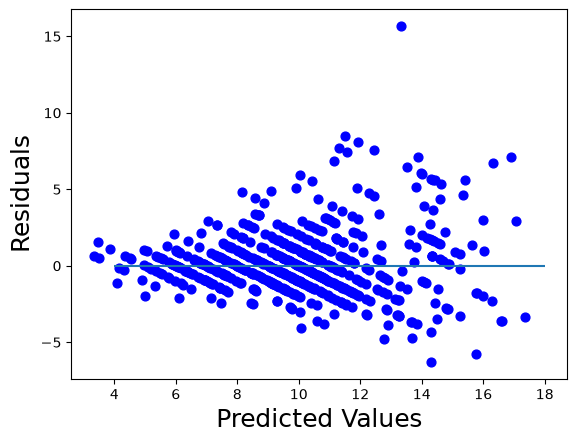

In [10]:
# Visualization: a residual plot to compare the model predictions and ground truth targets. For each example, the residual value
# is the subtraction between the prediction and ground truth target.
# We can see that the points in the residual plot are randomly dispersed around the horizontal axis y = 0,
# which indicates the fitted regression model is appropriate for the ABALONE data

residuals = ground_truth_label.values[:, 0] - model_predictions
plt.scatter(model_predictions, residuals, color="blue", s=40)
plt.hlines(y=0, xmin=4, xmax=18)
plt.xlabel("Predicted Values", fontsize=18)
plt.ylabel("Residuals", fontsize=18)
plt.show()

In [11]:
# Evaluate the model predictions quantitatively.
eval_r2_score = r2_score(ground_truth_label.values, model_predictions)
eval_mse_score = mean_squared_error(ground_truth_label.values, model_predictions)
eval_mae_score = mean_absolute_error(ground_truth_label.values, model_predictions)
print(
    f"{bold}Evaluation result on test data{unbold}:{newline}"
    f"{bold}{r2_score.__name__}{unbold}: {eval_r2_score}{newline}"
    f"{bold}{mean_squared_error.__name__}{unbold}: {eval_mse_score}{newline}"
    f"{bold}{mean_absolute_error.__name__}{unbold}: {eval_mae_score}{newline}"
)

Evaluation result on test data:
r2_score: 0.6108650775322776
mean_squared_error: 4.4532511712817255
mean_absolute_error: 1.4510031641481784



---
Next, we delete the endpoint corresponding to the trained model.

---

In [12]:
# Delete the SageMaker endpoint and the attached resources
from sagemaker.core.resources import EndpointConfig

endpoint_config = EndpointConfig.get(endpoint_config_name=predictor.endpoint_name)

if model is not None:
    model.delete()
predictor.delete()
endpoint_config.delete()

[07/09/26 14:03:16] INFO     Deleting Model - model-d461c72a                                     ]8;id=12075990;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12075991;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

                    INFO     Deleting Endpoint - endpoint-68e2559a                               ]8;id=12075997;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12075998;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig - endpoint-68e2559a                         ]8;id=12076004;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12076005;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/build_and_train_models|sm-introduction_to_auogluon_tabular_regression.ipynb)
